# Used Car Price Dataset - Professional EDA

This notebook performs a production-style exploratory data analysis for the used car dataset.

## Objectives
- Validate data quality (missing values, duplicates, data types, edge cases)
- Understand feature distributions and category composition
- Analyze relationships with target variable `price`
- Export high-quality charts to `01-eda/outputs/` for reporting and downstream use

In [1]:
# What this cell does: imports libraries, sets display/theme options, resolves project paths, and creates output folders.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def resolve_project_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "data" / "usedcars.csv").exists():
        return cwd
    if (cwd.parent / "data" / "usedcars.csv").exists():
        return cwd.parent
    raise FileNotFoundError("Could not locate data/usedcars.csv from current working directory.")


PROJECT_ROOT = resolve_project_root()
EDA_DIR = PROJECT_ROOT / "01-eda"
OUTPUT_DIR = EDA_DIR / "outputs"
SECTIONS = ["overview", "numerical", "categorical", "bivariate"]

for section in SECTIONS:
    (OUTPUT_DIR / section).mkdir(parents=True, exist_ok=True)


def save_fig(filename: str, section: str, dpi: int = 300) -> Path:
    out_path = OUTPUT_DIR / section / f"{filename}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    return out_path

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform
Output directory: C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\01-eda\outputs


## 1. Load Dataset

In [2]:
#loads the dataset and prints its path and shape for quick verification.
data_path = PROJECT_ROOT / "data" / "usedcars.csv"
df = pd.read_csv(data_path)

processed_dir = OUTPUT_DIR / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
print(f"Data loaded: shape {df.shape}")

Data loaded: shape (500, 29)


## 2. Structural Overview and Data Quality

In [3]:
# builds a data-quality overview table (types, nulls, uniqueness) and counts duplicate rows.
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "null_count": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values(["null_pct", "unique_values"], ascending=[False, False])

duplicate_rows = int(df.duplicated().sum())

print(f"Duplicate rows: {duplicate_rows}")
overview

Duplicate rows: 0


,dtype,non_null,null_count,null_pct,unique_values
stroke,float64,487,13,2.600,322
horsepower-binned,object,499,1,0.200,3
price,float64,500,0,0.000,482
curb-weight,int64,500,0,0.000,402
length,float64,500,0,0.000,370
horsepower,float64,500,0,0.000,357
wheel-base,float64,500,0,0.000,350
height,float64,500,0,0.000,345
width,float64,500,0,0.000,341
bore,float64,500,0,0.000,332


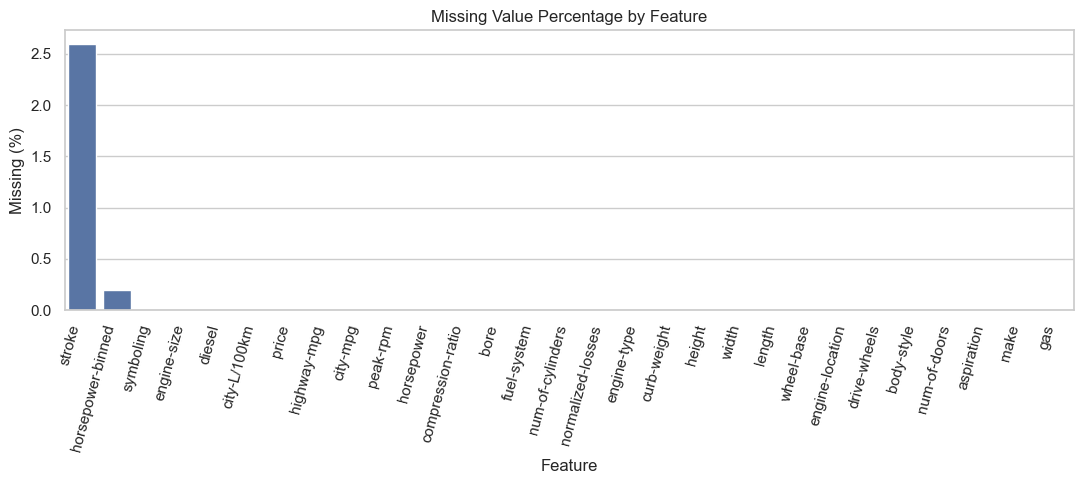

Saved: C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\01-eda\outputs\overview\missing-value-percentage.png


In [4]:
# visualizes feature-level missing value percentages and saves the chart.
missing_plot = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 5))
ax = sns.barplot(x=missing_plot.index, y=missing_plot.values, color="#4C72B0")
ax.set_title("Missing Value Percentage by Feature")
ax.set_xlabel("Feature")
ax.set_ylabel("Missing (%)")
plt.xticks(rotation=75, ha="right")

out = save_fig("missing-value-percentage", "overview")
plt.show()
print(f"Saved: {out}")

## 3. Target Variable (`price`) Overview

In [5]:
# computes descriptive statistics for the target variable `price`.
price_stats = df["price"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("price")
price_stats

,price
count,500.000
mean,"13,110.746"
std,"7,585.959"
min,"5,118.000"
5%,"5,860.630"
25%,"7,857.239"
50%,"10,587.988"
75%,"16,318.541"
95%,"31,518.914"
max,"45,400.000"


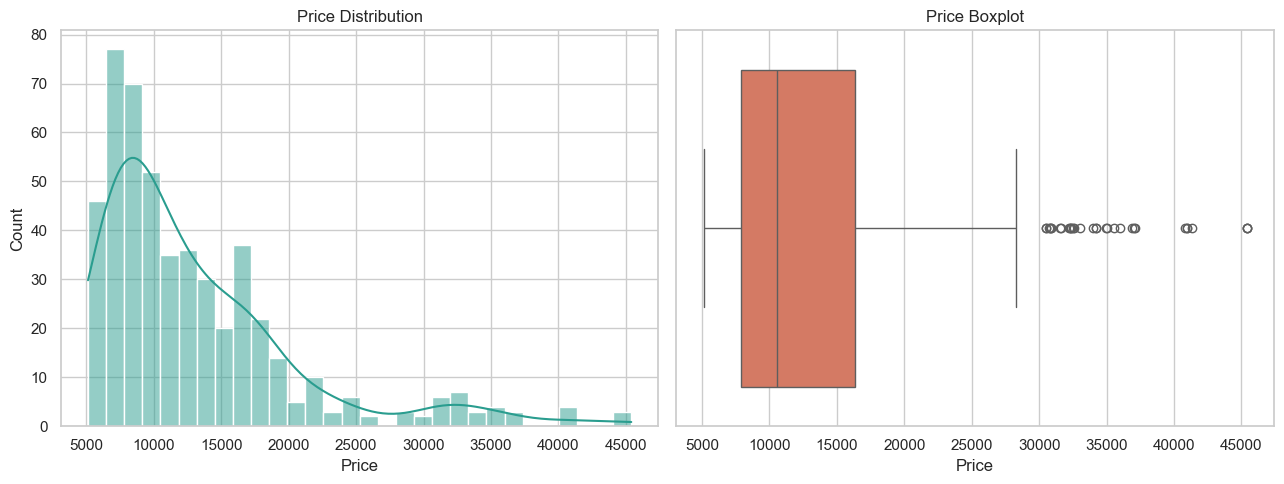

Saved: C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\01-eda\outputs\overview\price-distribution-and-boxplot.png


In [6]:
# plots the target distribution (histogram + boxplot) and saves the figure.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["price"], kde=True, bins=30, ax=axes[0], color="#2A9D8F")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price")

sns.boxplot(x=df["price"], ax=axes[1], color="#E76F51")
axes[1].set_title("Price Boxplot")
axes[1].set_xlabel("Price")

out = save_fig("price-distribution-and-boxplot", "overview")
plt.show()
print(f"Saved: {out}")

## 4. Numerical Feature Analysis

In [7]:
# identifies numeric columns and creates a statistical summary including missing % and IQR.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_without_target = [c for c in numeric_cols if c != "price"]

num_summary = df[numeric_cols].describe().T
num_summary["missing_pct"] = (df[numeric_cols].isna().mean() * 100).round(2)
num_summary["iqr"] = num_summary["75%"] - num_summary["25%"]
num_summary = num_summary.sort_values("std", ascending=False)
num_summary

,count,mean,std,min,25%,50%,75%,max,missing_pct,iqr
price,500.000,"13,110.746","7,585.959","5,118.000","7,857.239","10,587.988","16,318.541","45,400.000",0.000,"8,461.302"
curb-weight,500.000,"2,549.668",493.673,"1,488.000","2,190.750","2,443.000","2,910.500","4,066.000",0.000,719.750
peak-rpm,500.000,"5,132.319",467.666,"4,150.000","4,800.000","5,183.689","5,488.639","6,600.000",0.000,688.639
engine-size,500.000,125.924,40.343,61.000,98.000,119.000,141.000,326.000,0.000,43.000
horsepower,500.000,103.253,36.455,48.000,70.000,95.218,116.000,262.000,0.000,46.000
normalized-losses,500.000,123.876,33.703,65.000,102.000,122.000,145.000,256.000,0.000,43.000
highway-mpg,500.000,30.340,6.521,16.000,25.000,30.000,34.000,54.000,0.000,9.000
city-mpg,500.000,24.856,6.262,13.000,19.000,24.000,29.250,49.000,0.000,10.250
wheel-base,500.000,98.677,5.931,86.600,94.505,96.974,101.200,120.900,0.000,6.695
compression-ratio,500.000,9.900,3.589,7.000,8.600,9.005,9.399,23.000,0.000,0.799


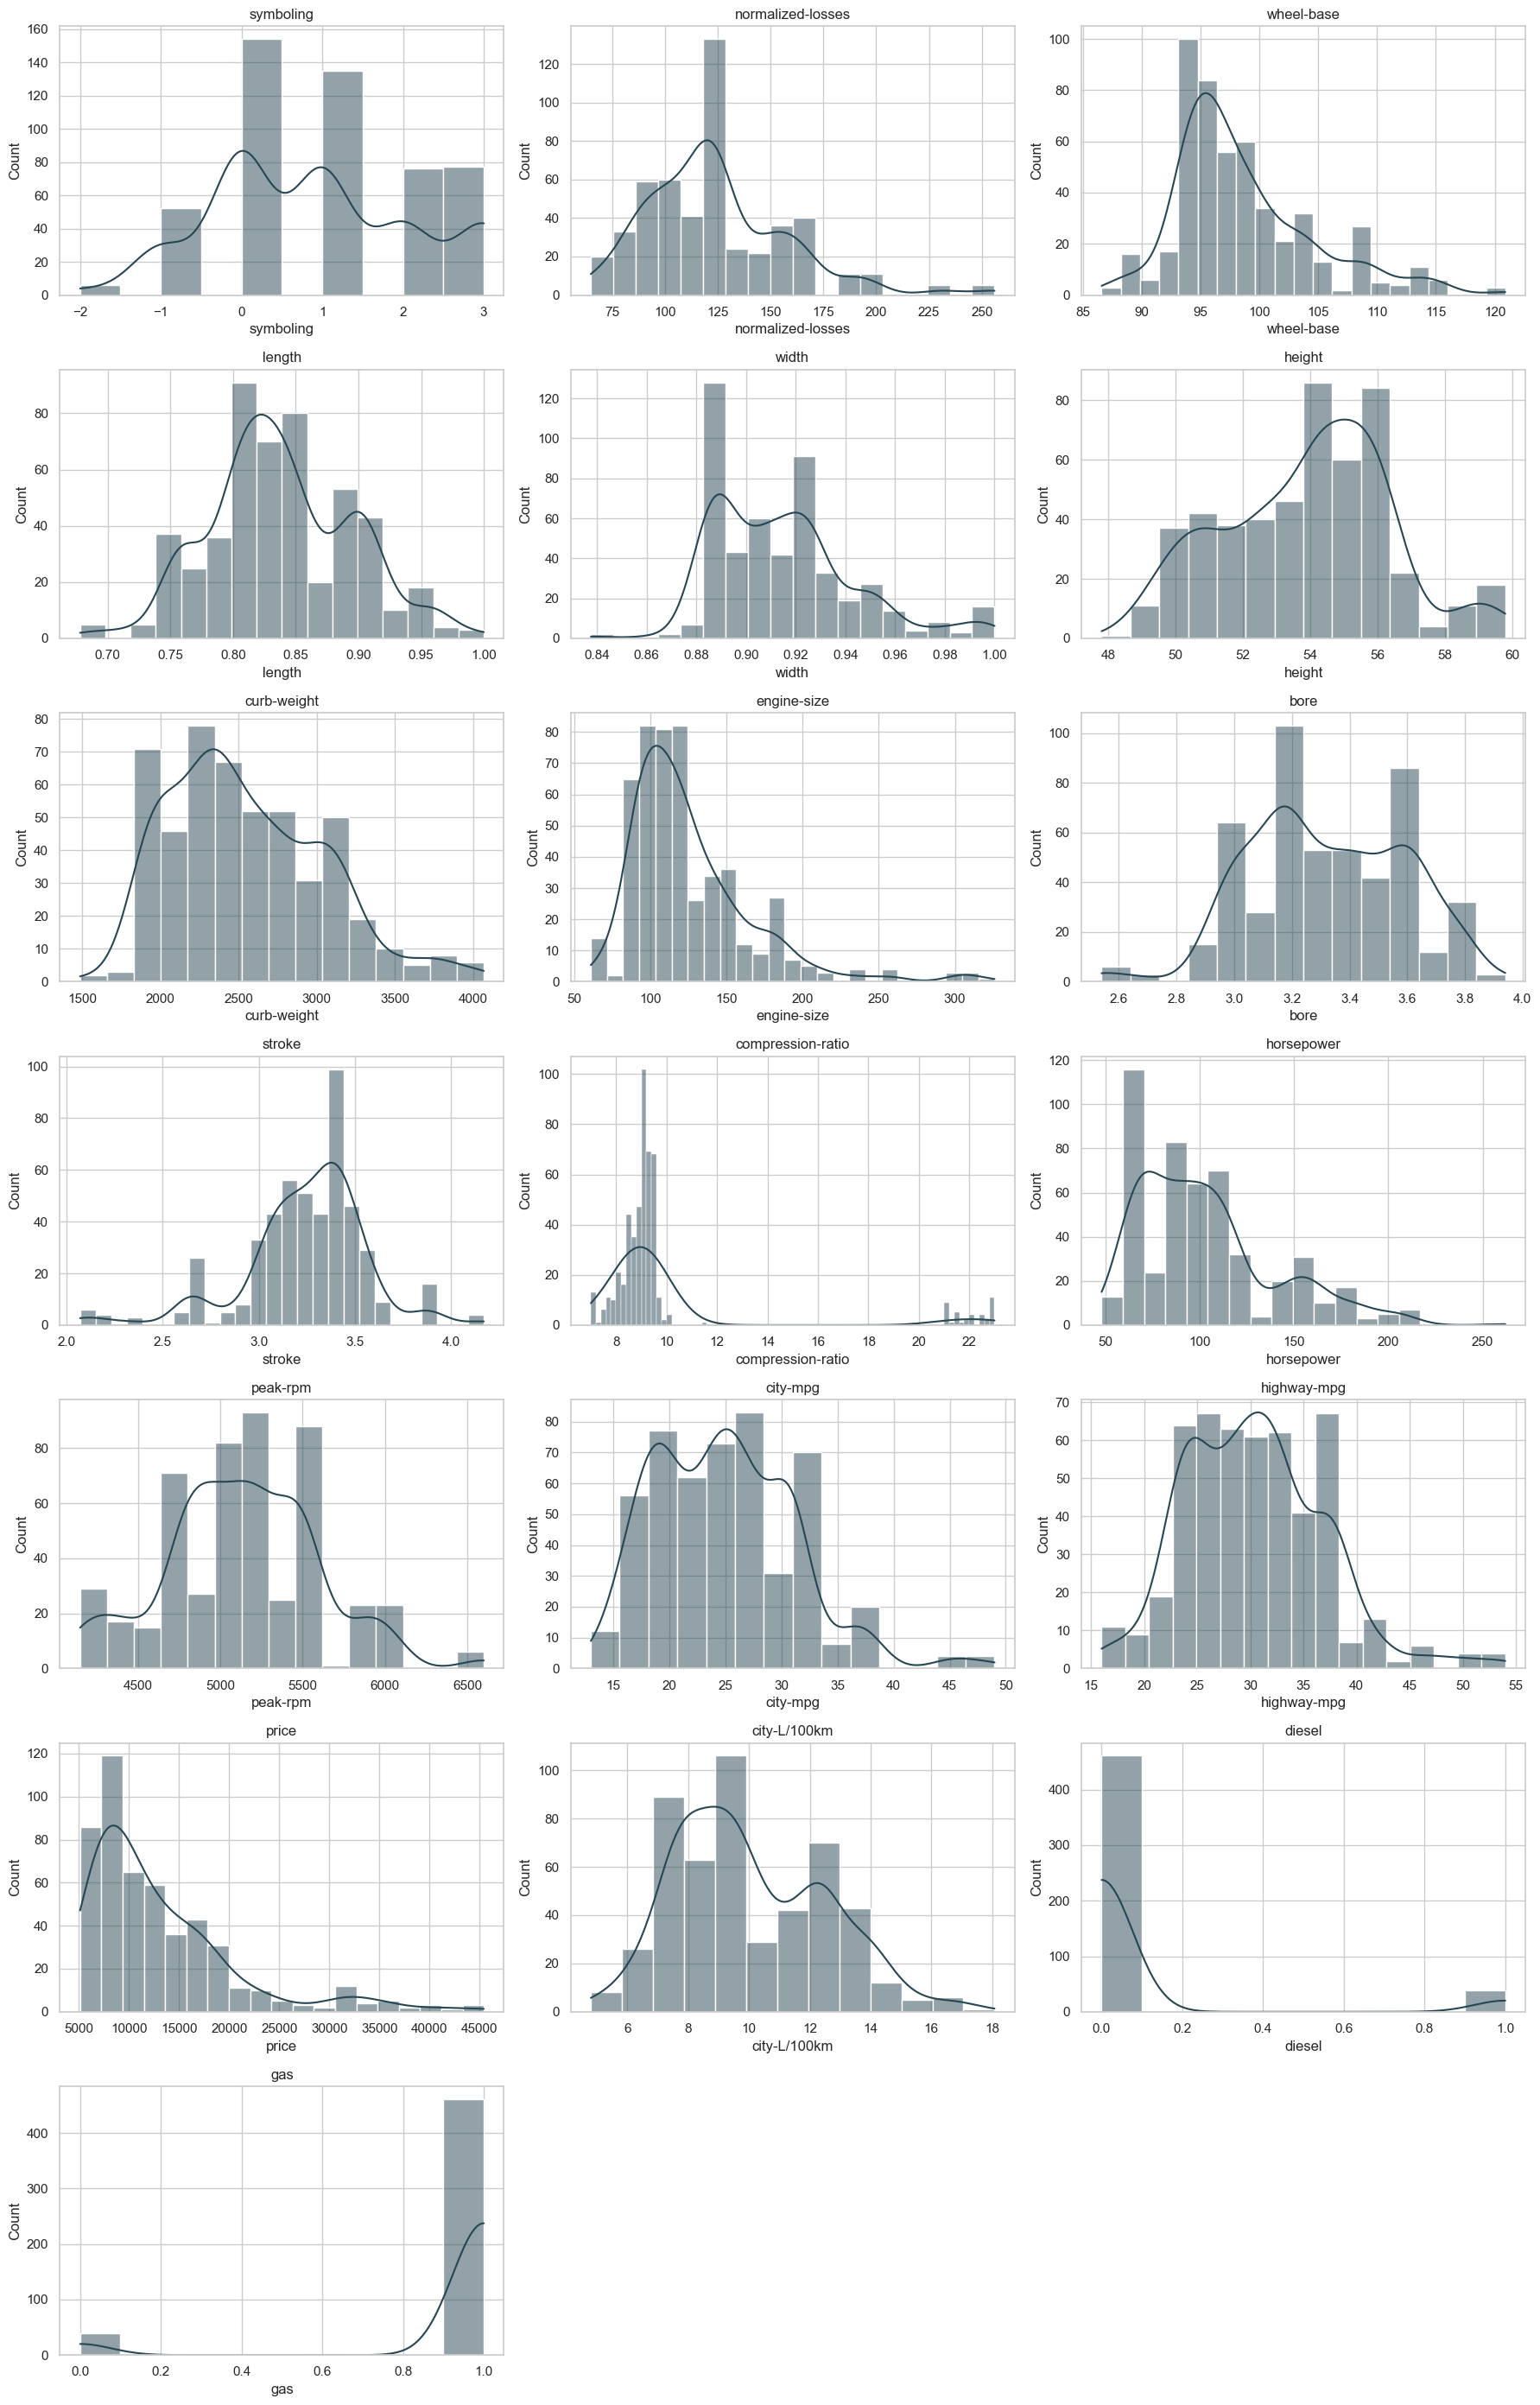

Saved: C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\01-eda\outputs\numerical\numeric-histograms.png


In [8]:
# draws histograms for all numeric features and saves the combined plot.
plot_cols = numeric_cols
n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(plot_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color="#264653")
    axes[idx].set_title(col)

for idx in range(len(plot_cols), len(axes)):
    axes[idx].axis("off")

out = save_fig("numeric-histograms", "numerical")
plt.show()
print(f"Saved: {out}")

In [9]:
# calculates IQR-based outlier counts for each numeric feature.
# IQR-based outlier count per numeric feature
outlier_counts = {}
for col in numeric_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = int(((s < lower) | (s > upper)).sum())

outlier_df = pd.DataFrame({
    "feature": list(outlier_counts.keys()),
    "outlier_count": list(outlier_counts.values())
}).sort_values("outlier_count", ascending=False)
outlier_df

,feature,outlier_count
10,compression-ratio,54
18,gas,39
17,diesel,39
15,price,32
2,wheel-base,24
7,engine-size,23
9,stroke,22
4,width,19
11,horsepower,13
1,normalized-losses,10


## 5. Categorical Feature Analysis

In [10]:
# identifies categorical columns and summarizes their cardinality and missing percentages.
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

cat_summary = pd.DataFrame({
    "feature": categorical_cols,
    "unique_values": [df[c].nunique() for c in categorical_cols],
    "missing_pct": [(df[c].isna().mean() * 100).round(2) for c in categorical_cols]
}).sort_values(["unique_values", "missing_pct"], ascending=[False, False])

cat_summary

,feature,unique_values,missing_pct
0,make,22,0.000
8,fuel-system,8,0.000
7,num-of-cylinders,7,0.000
6,engine-type,6,0.000
3,body-style,5,0.000
9,horsepower-binned,3,0.200
4,drive-wheels,3,0.000
1,aspiration,2,0.000
2,num-of-doors,2,0.000
5,engine-location,2,0.000


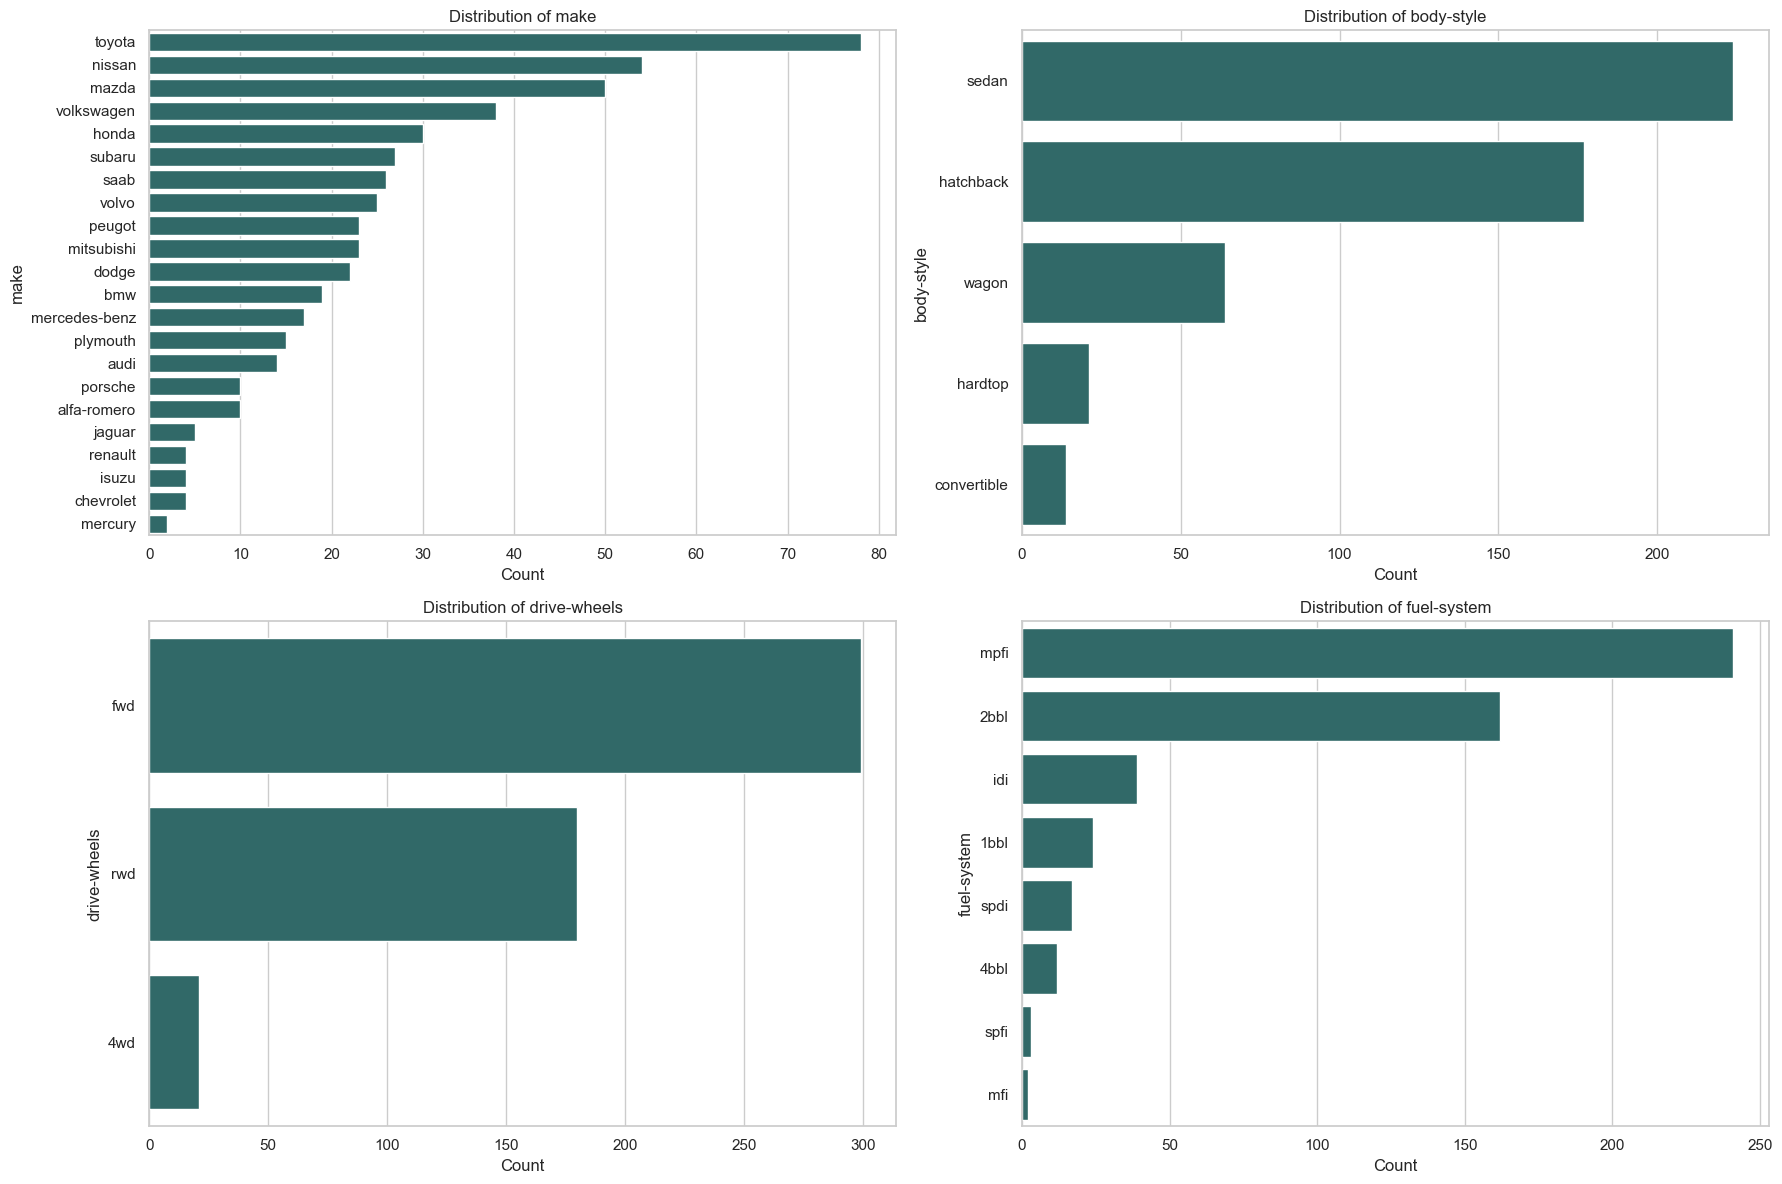

Saved: C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\01-eda\outputs\categorical\categorical-countplots.png


In [11]:
# plots key categorical feature distributions (countplots) and saves the figure.
top_cat_features = ["make", "body-style", "drive-wheels", "fuel-system"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(top_cat_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], color="#287271")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel(col)

out = save_fig("categorical-countplots", "categorical")
plt.show()
print(f"Saved: {out}")

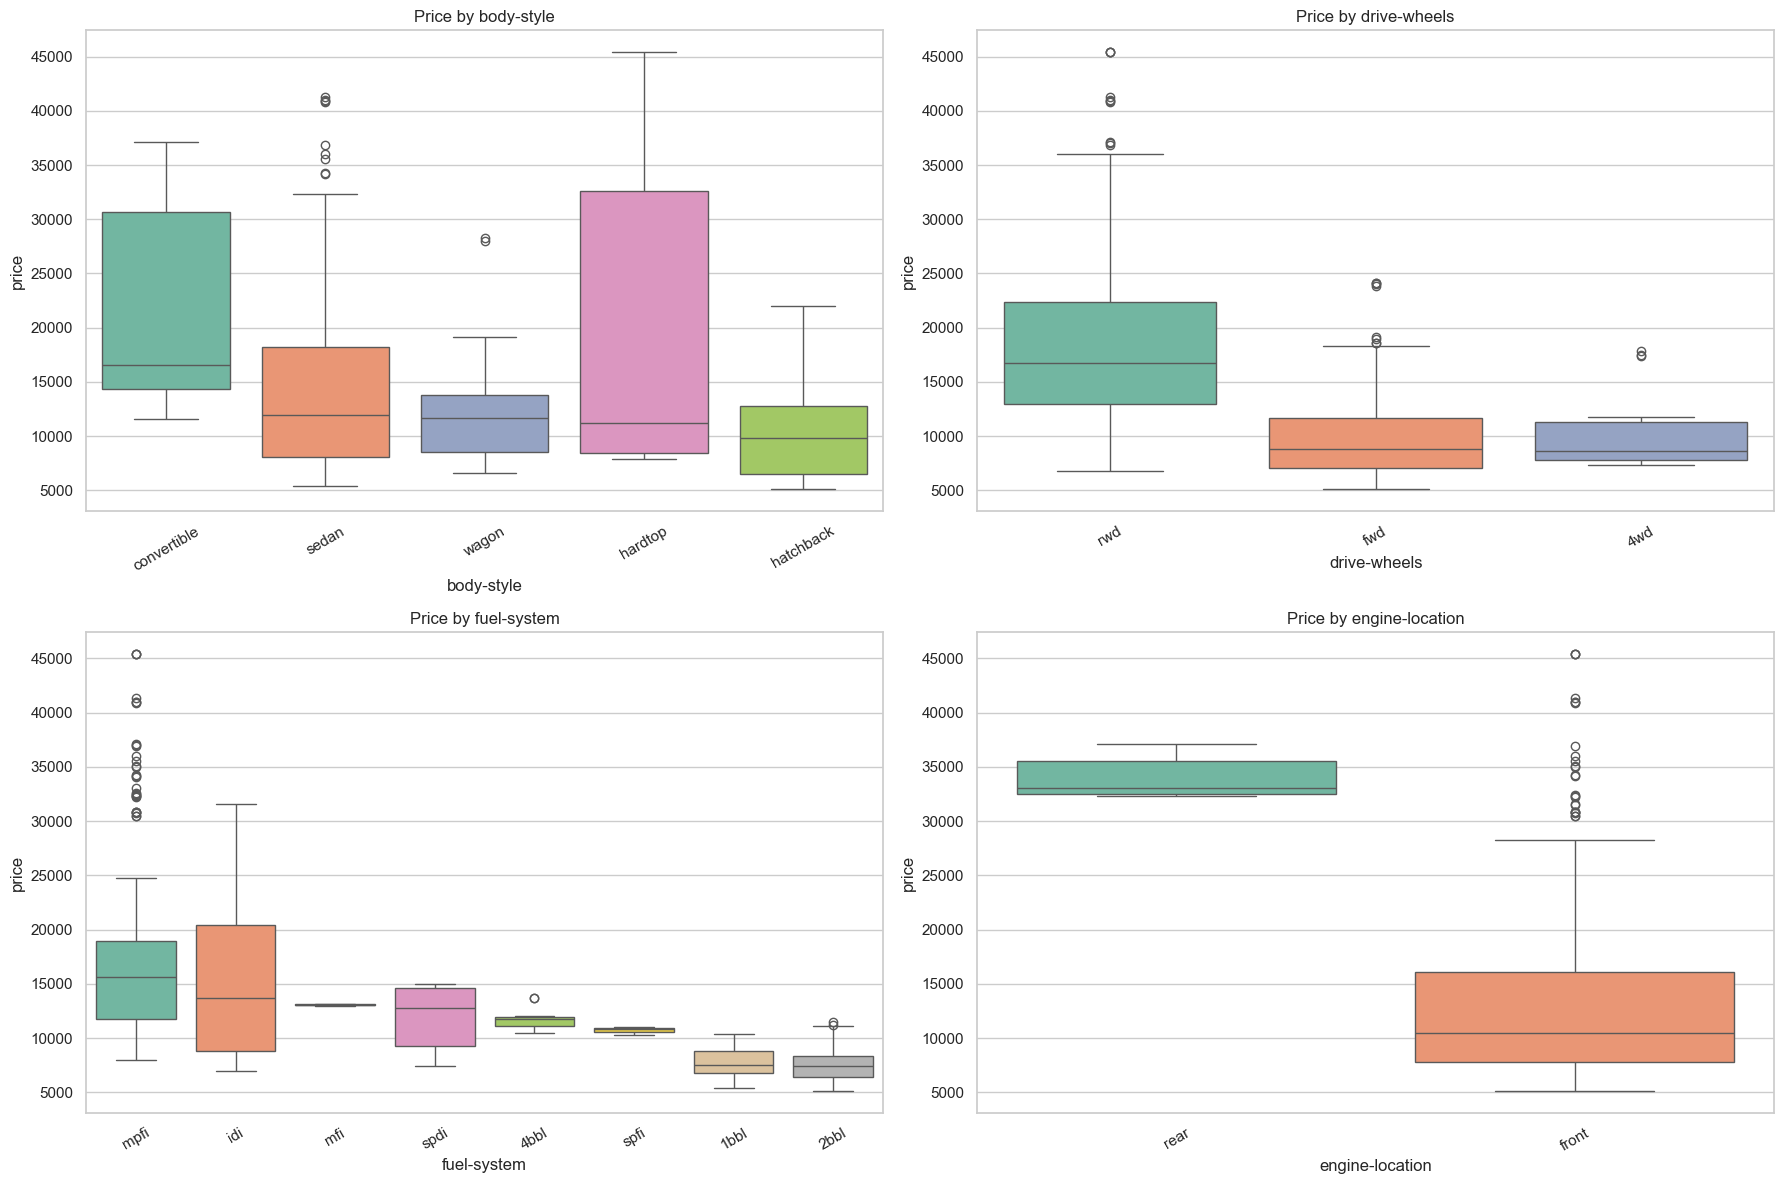

Saved: C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\01-eda\outputs\categorical\price-vs-categorical-boxplots.png


In [12]:
# compares `price` distributions across major categorical groups using boxplots.
price_by_categories = ["body-style", "drive-wheels", "fuel-system", "engine-location"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(price_by_categories):
    order = df.groupby(col)["price"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y="price", order=order, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Price by {col}")
    axes[i].tick_params(axis="x", rotation=30)

out = save_fig("price-vs-categorical-boxplots", "categorical")
plt.show()
print(f"Saved: {out}")

## 6. Bivariate Relationships With Price

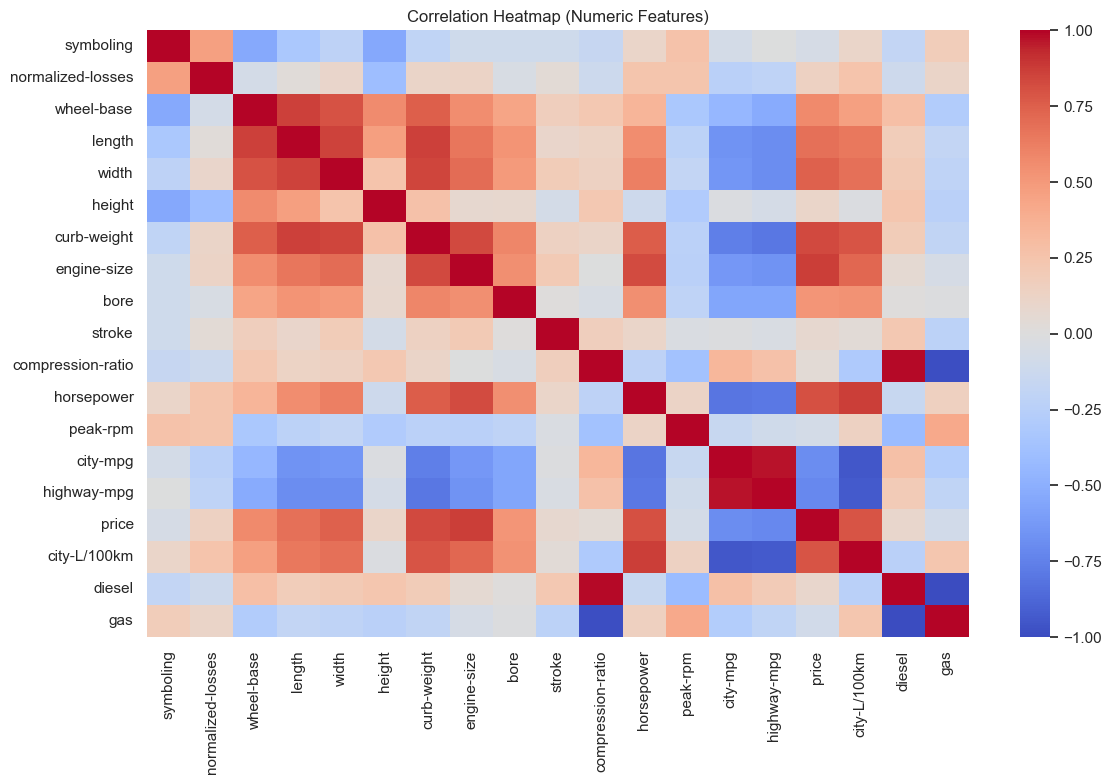

Saved: C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\01-eda\outputs\bivariate\correlation-heatmap.png


,corr_with_price
price,1.000
engine-size,0.872
curb-weight,0.829
horsepower,0.811
city-L/100km,0.793
width,0.747
length,0.685
wheel-base,0.573
bore,0.518
normalized-losses,0.148


In [13]:
# computes correlations, visualizes a heatmap, and lists correlation strength with `price`.
corr = df[numeric_cols].corr(numeric_only=True)
price_corr = corr["price"].sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numeric Features)")

out = save_fig("correlation-heatmap", "bivariate")
plt.show()
print(f"Saved: {out}")

price_corr.to_frame("corr_with_price")

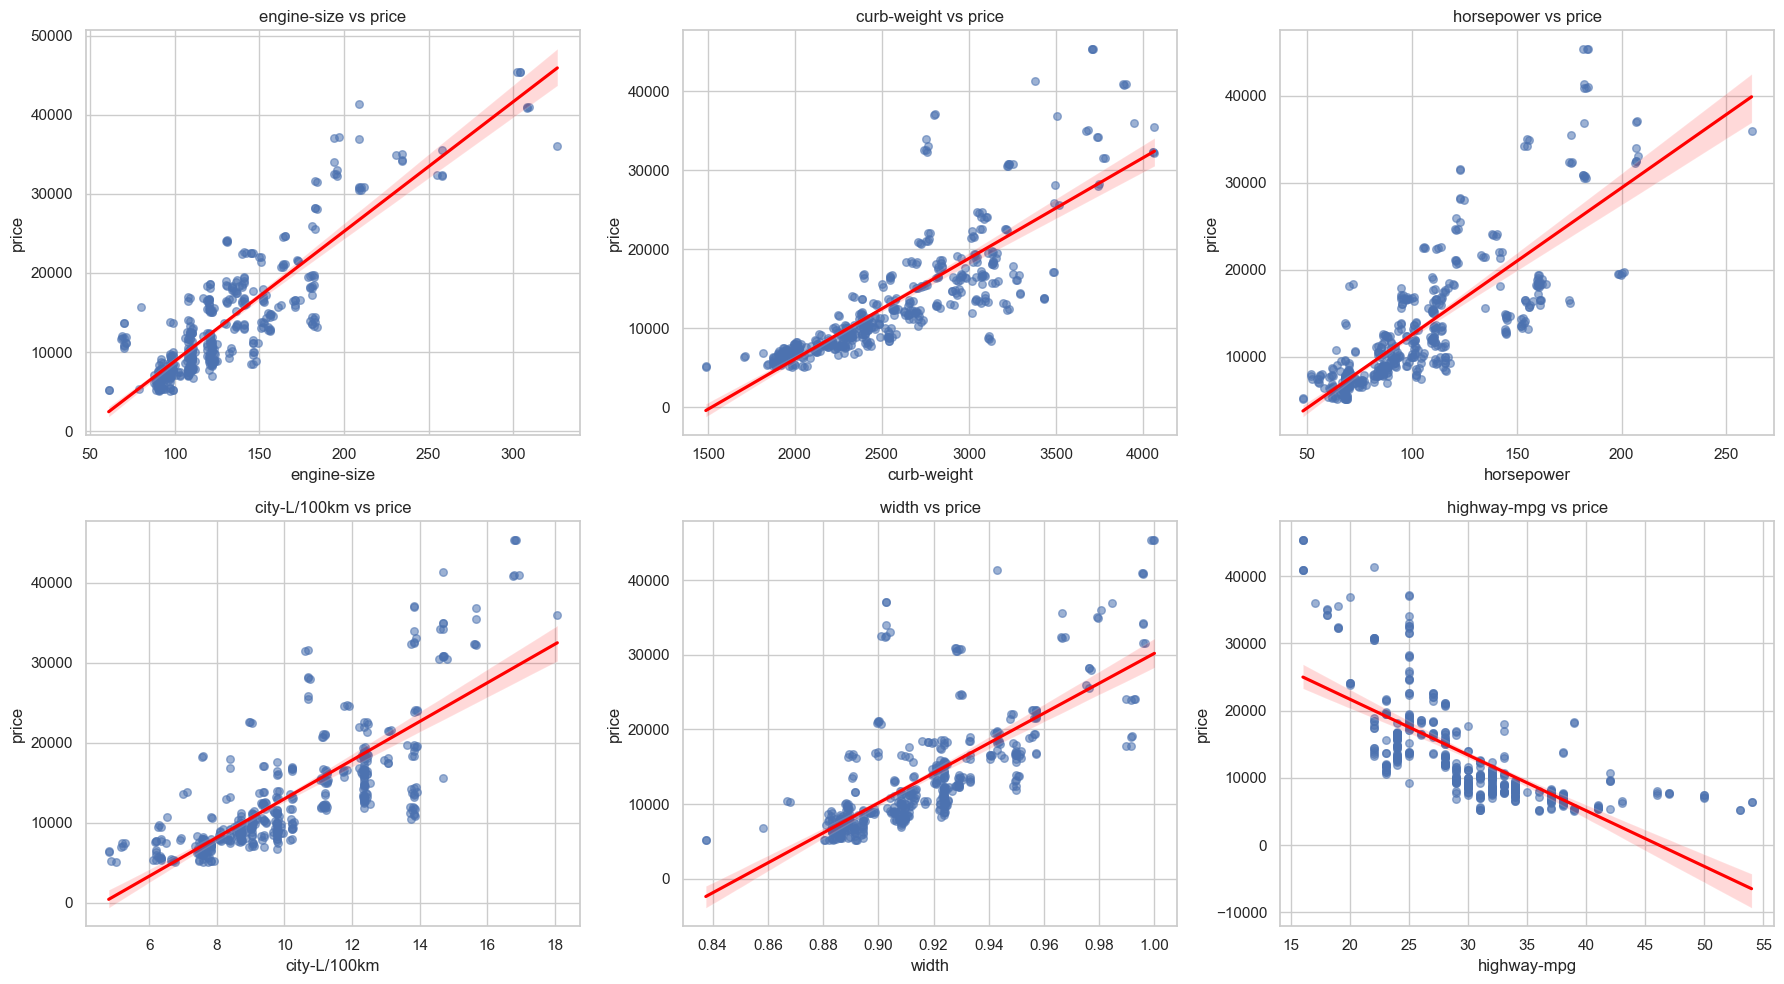

Saved: C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\01-eda\outputs\bivariate\top-regression-plots-with-price.png


In [14]:
# selects top correlated numeric features and creates regression plots vs `price`.
top_numeric_rel = (
    price_corr.drop(labels=["price"], errors="ignore")
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_numeric_rel):
    sns.regplot(data=df, x=col, y="price", scatter_kws={"alpha": 0.55, "s": 30}, line_kws={"color": "red"}, ax=axes[i])
    axes[i].set_title(f"{col} vs price")

for i in range(len(top_numeric_rel), len(axes)):
    axes[i].axis("off")

out = save_fig("top-regression-plots-with-price", "bivariate")
plt.show()
print(f"Saved: {out}")

## 7. Business-Focused Summary

In [15]:
# builds a compact KPI summary table for business-facing reporting.
summary_table = pd.DataFrame({
    "metric": [
        "row_count", "column_count", "duplicate_rows", "price_mean", "price_median", "price_min", "price_max"
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        int(df.duplicated().sum()),
        float(df["price"].mean()),
        float(df["price"].median()),
        float(df["price"].min()),
        float(df["price"].max())
    ]
})
summary_table

,metric,value
0,row_count,500.000
1,column_count,29.000
2,duplicate_rows,0.000
3,price_mean,"13,110.746"
4,price_median,"10,587.988"
5,price_min,"5,118.000"
6,price_max,"45,400.000"


### Key EDA Findings
- Dataset is compact and model-ready after minor missing value handling for a few features.
- `price` shows right-skewness, suggesting log transformation can be tested during modeling.
- Strong numeric relationships with `price` typically appear around engine/power/weight dimensions.
- Categorical groups such as `engine-location`, `drive-wheels`, and `body-style` show clear price separation.

### Recommended Next Steps
1. Impute missing numeric values (`stroke`) and validate outlier treatment strategy.
2. Encode key categorical variables and evaluate feature interactions.
3. Compare baseline linear models with transformed-target variants (for skew control).

In [16]:
# Full cleaning pipeline for export to downstream stages
# Load fresh copy of raw data
df_clean = pd.read_csv(data_path)

# 1. Identify categorical columns BEFORE numeric conversion
categorical_cols = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()

# 2. Drop rows with missing target
df_clean.dropna(subset=["price"], inplace=True)

# 3. One-hot encode categorical features (before numeric conversion)
if categorical_cols:
    df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# 4. Convert all columns to numeric
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# 5. Impute missing numeric values with median
numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols_clean:
    if df_clean[col].isna().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Export cleaned dataset
stage1_snapshot_path = processed_dir / "usedcars_stage1.csv"
df_clean.to_csv(stage1_snapshot_path, index=False)

print(f"✓ Cleaned dataset exported to {stage1_snapshot_path}")
print(f"  Shape: {df_clean.shape}")
print(f"  Missing values: {df_clean.isna().sum().sum()}")
print(f"  All numeric: {df_clean.select_dtypes(exclude=[np.number]).shape[1] == 0}")

✓ Cleaned dataset exported to C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\01-eda\outputs\processed\usedcars_stage1.csv
  Shape: (500, 69)
  Missing values: 0
  All numeric: False


## 8. Export Cleaned Dataset for Downstream Stages